In [1]:
import requests
import pandas as pd

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": 60
}

r = requests.get(url, params=params)

data = r.json()

prices = data["prices"]

df = pd.DataFrame(prices, columns=["time", "price"])

df["time"] = pd.to_datetime(df["time"], unit="ms")

df.head()  #获取行情数据

,time,price
0,2026-01-16 14:01:21.615,95408.757499
1,2026-01-16 15:00:26.880,95197.562430
2,2026-01-16 16:02:01.123,94564.218778
3,2026-01-16 17:02:45.958,94774.674228
4,2026-01-16 18:00:39.354,94942.201463


In [2]:
df["return"] = df["price"].pct_change()

df.head()   #每个时间点的涨跌幅

,time,price,return
0,2026-01-16 14:01:21.615,95408.757499,NaN
1,2026-01-16 15:00:26.880,95197.562430,-0.002214
2,2026-01-16 16:02:01.123,94564.218778,-0.006653
3,2026-01-16 17:02:45.958,94774.674228,0.002226
4,2026-01-16 18:00:39.354,94942.201463,0.001768


In [3]:
df["rolling_vol"] = df["return"].rolling(20).std()

df.tail()  #最近20个时间点波动率

,time,price,return,rolling_vol
1437,2026-03-17 10:02:50.920,73931.428691,-0.003446,0.004520
1438,2026-03-17 11:02:59.217,73727.015903,-0.002765,0.004199
1439,2026-03-17 12:04:01.536,74049.990253,0.004381,0.004249
1440,2026-03-17 13:00:04.364,73716.499024,-0.004504,0.004119
1441,2026-03-17 13:56:23.000,73563.709410,-0.002073,0.004096


In [4]:
exposure = 100000

z = 1.65

df["rolling_var"] = exposure * df["rolling_vol"] * z

df.tail() #rolling VaR

,time,price,return,rolling_vol,rolling_var
1437,2026-03-17 10:02:50.920,73931.428691,-0.003446,0.004520,745.729951
1438,2026-03-17 11:02:59.217,73727.015903,-0.002765,0.004199,692.867674
1439,2026-03-17 12:04:01.536,74049.990253,0.004381,0.004249,701.029610
1440,2026-03-17 13:00:04.364,73716.499024,-0.004504,0.004119,679.650133
1441,2026-03-17 13:56:23.000,73563.709410,-0.002073,0.004096,675.846614


In [5]:
balance = 20000

df["risk_ratio"] = exposure / balance

df.tail() #risk ritio

,time,price,return,rolling_vol,rolling_var,risk_ratio
1437,2026-03-17 10:02:50.920,73931.428691,-0.003446,0.004520,745.729951,5.0
1438,2026-03-17 11:02:59.217,73727.015903,-0.002765,0.004199,692.867674,5.0
1439,2026-03-17 12:04:01.536,74049.990253,0.004381,0.004249,701.029610,5.0
1440,2026-03-17 13:00:04.364,73716.499024,-0.004504,0.004119,679.650133,5.0
1441,2026-03-17 13:56:23.000,73563.709410,-0.002073,0.004096,675.846614,5.0


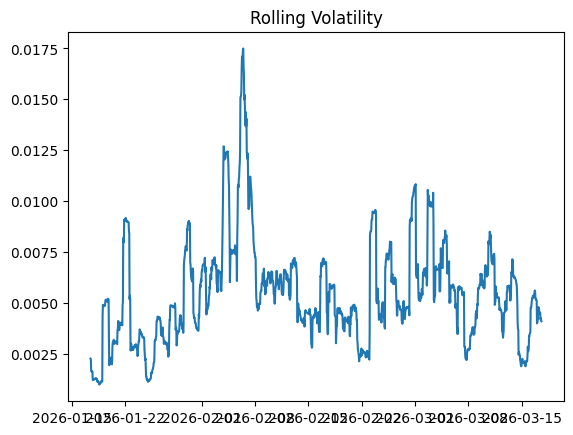

In [6]:
import matplotlib.pyplot as plt

plt.plot(df["time"], df["rolling_vol"])

plt.title("Rolling Volatility")

plt.show()

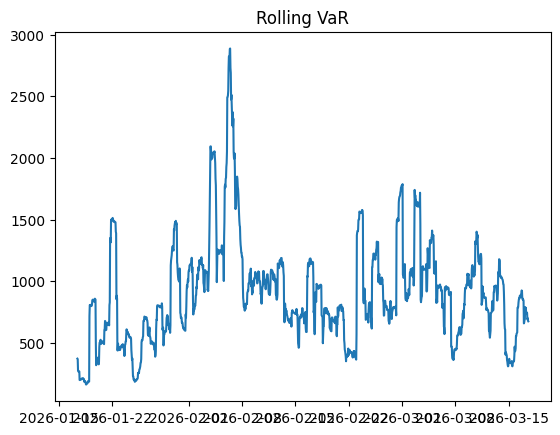

In [7]:
plt.plot(df["time"], df["rolling_var"])

plt.title("Rolling VaR")

plt.show()

In [8]:
threshold = 5000

df["alert"] = df["rolling_var"] > threshold

df.tail() #风险报警

,time,price,return,rolling_vol,rolling_var,risk_ratio,alert
1437,2026-03-17 10:02:50.920,73931.428691,-0.003446,0.004520,745.729951,5.0,False
1438,2026-03-17 11:02:59.217,73727.015903,-0.002765,0.004199,692.867674,5.0,False
1439,2026-03-17 12:04:01.536,74049.990253,0.004381,0.004249,701.029610,5.0,False
1440,2026-03-17 13:00:04.364,73716.499024,-0.004504,0.004119,679.650133,5.0,False
1441,2026-03-17 13:56:23.000,73563.709410,-0.002073,0.004096,675.846614,5.0,False


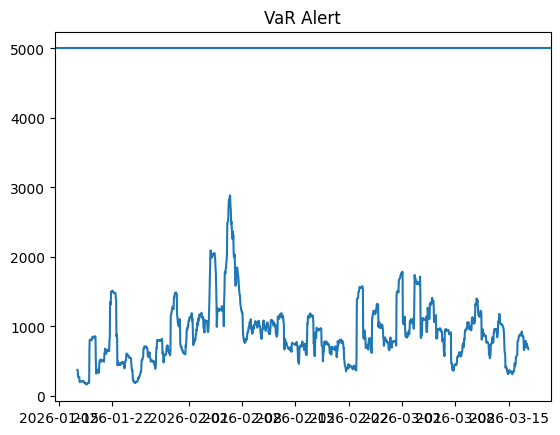

In [9]:
plt.plot(df["time"], df["rolling_var"])

plt.axhline(5000)

plt.title("VaR Alert")

plt.show()

In [10]:
import numpy as np

accounts = []

for i in range(20):

    exposure = np.random.randint(10000, 200000)

    balance = np.random.randint(5000, 50000)

    accounts.append([i, exposure, balance])

acc_df = pd.DataFrame(accounts, columns=["account", "exposure", "balance"])

acc_df["risk_ratio"] = acc_df["exposure"] / acc_df["balance"]

acc_df  #多账户风险率

,account,exposure,balance,risk_ratio
0,0,166916,28693,5.817307
1,1,37391,31318,1.193914
2,2,102203,48974,2.086883
3,3,186252,24789,7.513494
4,4,106682,10138,10.522983
5,5,157119,22875,6.868590
6,6,21481,19395,1.107553
7,7,115963,25838,4.488080
8,8,183664,12764,14.389220
9,9,119505,22310,5.356567


In [11]:
whale = acc_df[acc_df["exposure"] > 150000]

whale #whale monitor

,account,exposure,balance,risk_ratio
0,0,166916,28693,5.817307
3,3,186252,24789,7.513494
5,5,157119,22875,6.868590
8,8,183664,12764,14.389220
16,16,151168,41769,3.619143


In [12]:
high_risk = acc_df[acc_df["risk_ratio"] > 5]

high_risk

,account,exposure,balance,risk_ratio
0,0,166916,28693,5.817307
3,3,186252,24789,7.513494
4,4,106682,10138,10.522983
5,5,157119,22875,6.868590
8,8,183664,12764,14.389220
9,9,119505,22310,5.356567
14,14,142903,20711,6.899860
15,15,59067,6618,8.925204
18,18,86184,10769,8.002971


In [13]:
latest_var = df["rolling_var"].iloc[-1]

acc_df["market_var"] = latest_var

acc_df["total_risk"] = acc_df["risk_ratio"] * latest_var

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk
0,0,166916,28693,5.817307,675.846614,3931.607478
1,1,37391,31318,1.193914,675.846614,806.902763
2,2,102203,48974,2.086883,675.846614,1410.412698
3,3,186252,24789,7.513494,675.846614,5077.969401
4,4,106682,10138,10.522983,675.846614,7111.922316
5,5,157119,22875,6.868590,675.846614,4642.113403
6,6,21481,19395,1.107553,675.846614,748.536278
7,7,115963,25838,4.488080,675.846614,3033.253381
8,8,183664,12764,14.389220,675.846614,9724.905394
9,9,119505,22310,5.356567,675.846614,3620.217372


In [14]:
acc_df["alert"] = acc_df["total_risk"] > 20000

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk,alert
0,0,166916,28693,5.817307,675.846614,3931.607478,False
1,1,37391,31318,1.193914,675.846614,806.902763,False
2,2,102203,48974,2.086883,675.846614,1410.412698,False
3,3,186252,24789,7.513494,675.846614,5077.969401,False
4,4,106682,10138,10.522983,675.846614,7111.922316,False
5,5,157119,22875,6.868590,675.846614,4642.113403,False
6,6,21481,19395,1.107553,675.846614,748.536278,False
7,7,115963,25838,4.488080,675.846614,3033.253381,False
8,8,183664,12764,14.389220,675.846614,9724.905394,False
9,9,119505,22310,5.356567,675.846614,3620.217372,False


In [15]:
alerts = acc_df[acc_df["alert"] == True]

alerts

,account,exposure,balance,risk_ratio,market_var,total_risk,alert


In [16]:
acc_df["whale"] = acc_df["exposure"] > 150000

acc_df  #whale + risk

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True
1,1,37391,31318,1.193914,675.846614,806.902763,False,False
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False
5,5,157119,22875,6.868590,675.846614,4642.113403,False,True
6,6,21481,19395,1.107553,675.846614,748.536278,False,False
7,7,115963,25838,4.488080,675.846614,3033.253381,False,False
8,8,183664,12764,14.389220,675.846614,9724.905394,False,True
9,9,119505,22310,5.356567,675.846614,3620.217372,False,False


In [17]:
liquidation_threshold = 5 #风险率 > 5 就强平

In [18]:
acc_df["liquidation"] = acc_df["risk_ratio"] > liquidation_threshold

acc_df #true= 强平

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True,True
1,1,37391,31318,1.193914,675.846614,806.902763,False,False,False
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False,False
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True,True
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False,True
5,5,157119,22875,6.868590,675.846614,4642.113403,False,True,True
6,6,21481,19395,1.107553,675.846614,748.536278,False,False,False
7,7,115963,25838,4.488080,675.846614,3033.253381,False,False,False
8,8,183664,12764,14.389220,675.846614,9724.905394,False,True,True
9,9,119505,22310,5.356567,675.846614,3620.217372,False,False,True


In [19]:
mark_price = df["price"].iloc[-1]

acc_df["mark_price"] = mark_price

acc_df["bankrupt_price"] = acc_df["mark_price"] * (1 - 1/acc_df["risk_ratio"])

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True,True,73563.70941,60918.046238
1,1,37391,31318,1.193914,675.846614,806.902763,False,False,False,73563.70941,11948.126748
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False,False,73563.70941,38313.187364
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True,True,73563.70941,63772.830426
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False,True,73563.70941,66572.943526
5,5,157119,22875,6.868590,675.846614,4642.113403,False,True,True,73563.70941,62853.547986
6,6,21481,19395,1.107553,675.846614,748.536278,False,False,False,73563.70941,7143.703637
7,7,115963,25838,4.488080,675.846614,3033.253381,False,False,False,73563.70941,57172.799174
8,8,183664,12764,14.389220,675.846614,9724.905394,False,True,True,73563.70941,68451.291152
9,9,119505,22310,5.356567,675.846614,3620.217372,False,False,True,73563.70941,59830.339619


In [20]:
acc_df["loss"] = acc_df["exposure"] * 0.1

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True,True,73563.70941,60918.046238,16691.6
1,1,37391,31318,1.193914,675.846614,806.902763,False,False,False,73563.70941,11948.126748,3739.1
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False,False,73563.70941,38313.187364,10220.3
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True,True,73563.70941,63772.830426,18625.2
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False,True,73563.70941,66572.943526,10668.2
5,5,157119,22875,6.868590,675.846614,4642.113403,False,True,True,73563.70941,62853.547986,15711.9
6,6,21481,19395,1.107553,675.846614,748.536278,False,False,False,73563.70941,7143.703637,2148.1
7,7,115963,25838,4.488080,675.846614,3033.253381,False,False,False,73563.70941,57172.799174,11596.3
8,8,183664,12764,14.389220,675.846614,9724.905394,False,True,True,73563.70941,68451.291152,18366.4
9,9,119505,22310,5.356567,675.846614,3620.217372,False,False,True,73563.70941,59830.339619,11950.5


In [21]:
insurance_fund = 500000

total_loss = acc_df.loc[acc_df["liquidation"], "loss"].sum()

insurance_fund_after = insurance_fund - total_loss

insurance_fund_after

np.float64(379170.8)

In [22]:
adl_trigger = insurance_fund_after < 0

adl_trigger #true =  ADL

np.False_

In [23]:
tiers = [
    (50000, 0.05),
    (100000, 0.1),
    (200000, 0.2),
    (999999999, 0.3)
]  #limit, margin_rate

In [24]:
def get_margin_rate(exposure):

    for limit, rate in tiers:

        if exposure <= limit:
            return rate #根据仓位返回保证金比例

In [25]:
acc_df["margin_rate"] = acc_df["exposure"].apply(get_margin_rate)

acc_df #计算账户保证金率

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True,True,73563.70941,60918.046238,16691.6,0.20
1,1,37391,31318,1.193914,675.846614,806.902763,False,False,False,73563.70941,11948.126748,3739.1,0.05
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False,False,73563.70941,38313.187364,10220.3,0.20
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True,True,73563.70941,63772.830426,18625.2,0.20
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False,True,73563.70941,66572.943526,10668.2,0.20
5,5,157119,22875,6.868590,675.846614,4642.113403,False,True,True,73563.70941,62853.547986,15711.9,0.20
6,6,21481,19395,1.107553,675.846614,748.536278,False,False,False,73563.70941,7143.703637,2148.1,0.05
7,7,115963,25838,4.488080,675.846614,3033.253381,False,False,False,73563.70941,57172.799174,11596.3,0.20
8,8,183664,12764,14.389220,675.846614,9724.905394,False,True,True,73563.70941,68451.291152,18366.4,0.20
9,9,119505,22310,5.356567,675.846614,3620.217372,False,False,True,73563.70941,59830.339619,11950.5,0.20


In [26]:
acc_df["maintenance_margin"] = acc_df["exposure"] * acc_df["margin_rate"]

acc_df #maitenance margin

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate,maintenance_margin
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True,True,73563.70941,60918.046238,16691.6,0.20,33383.20
1,1,37391,31318,1.193914,675.846614,806.902763,False,False,False,73563.70941,11948.126748,3739.1,0.05,1869.55
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False,False,73563.70941,38313.187364,10220.3,0.20,20440.60
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True,True,73563.70941,63772.830426,18625.2,0.20,37250.40
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False,True,73563.70941,66572.943526,10668.2,0.20,21336.40
5,5,157119,22875,6.868590,675.846614,4642.113403,False,True,True,73563.70941,62853.547986,15711.9,0.20,31423.80
6,6,21481,19395,1.107553,675.846614,748.536278,False,False,False,73563.70941,7143.703637,2148.1,0.05,1074.05
7,7,115963,25838,4.488080,675.846614,3033.253381,False,False,False,73563.70941,57172.799174,11596.3,0.20,23192.60
8,8,183664,12764,14.389220,675.846614,9724.905394,False,True,True,73563.70941,68451.291152,18366.4,0.20,36732.80
9,9,119505,22310,5.356567,675.846614,3620.217372,False,False,True,73563.70941,59830.339619,11950.5,0.20,23901.00


In [27]:
acc_df["liquidation_v2"] = acc_df["balance"] < acc_df["maintenance_margin"]

acc_df #liquidation = balance < maintenance margin

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate,maintenance_margin,liquidation_v2
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True,True,73563.70941,60918.046238,16691.6,0.20,33383.20,True
1,1,37391,31318,1.193914,675.846614,806.902763,False,False,False,73563.70941,11948.126748,3739.1,0.05,1869.55,False
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False,False,73563.70941,38313.187364,10220.3,0.20,20440.60,False
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True,True,73563.70941,63772.830426,18625.2,0.20,37250.40,True
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False,True,73563.70941,66572.943526,10668.2,0.20,21336.40,True
5,5,157119,22875,6.868590,675.846614,4642.113403,False,True,True,73563.70941,62853.547986,15711.9,0.20,31423.80,True
6,6,21481,19395,1.107553,675.846614,748.536278,False,False,False,73563.70941,7143.703637,2148.1,0.05,1074.05,False
7,7,115963,25838,4.488080,675.846614,3033.253381,False,False,False,73563.70941,57172.799174,11596.3,0.20,23192.60,False
8,8,183664,12764,14.389220,675.846614,9724.905394,False,True,True,73563.70941,68451.291152,18366.4,0.20,36732.80,True
9,9,119505,22310,5.356567,675.846614,3620.217372,False,False,True,73563.70941,59830.339619,11950.5,0.20,23901.00,True


In [28]:
acc_df[[
    "account",
    "exposure",
    "balance",
    "risk_ratio",
    "liquidation",
    "liquidation_v2"
]]

,account,exposure,balance,risk_ratio,liquidation,liquidation_v2
0,0,166916,28693,5.817307,True,True
1,1,37391,31318,1.193914,False,False
2,2,102203,48974,2.086883,False,False
3,3,186252,24789,7.513494,True,True
4,4,106682,10138,10.522983,True,True
5,5,157119,22875,6.868590,True,True
6,6,21481,19395,1.107553,False,False
7,7,115963,25838,4.488080,False,False
8,8,183664,12764,14.389220,True,True
9,9,119505,22310,5.356567,True,True


In [29]:
shock = -0.2   # 跌20%

In [30]:
current_price = df["price"].iloc[-1]

shock_price = current_price * (1 + shock)

shock_price

np.float64(58850.96752807053)

In [31]:
acc_df["price"] = current_price

acc_df["shock_price"] = shock_price

acc_df["pnl"] = (shock_price - current_price) / current_price * acc_df["exposure"]

acc_df["equity_after_shock"] = acc_df["balance"] + acc_df["pnl"]

acc_df #after shock

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate,maintenance_margin,liquidation_v2,price,shock_price,pnl,equity_after_shock
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True,True,73563.70941,60918.046238,16691.6,0.20,33383.20,True,73563.70941,58850.967528,-33383.2,-4690.2
1,1,37391,31318,1.193914,675.846614,806.902763,False,False,False,73563.70941,11948.126748,3739.1,0.05,1869.55,False,73563.70941,58850.967528,-7478.2,23839.8
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False,False,73563.70941,38313.187364,10220.3,0.20,20440.60,False,73563.70941,58850.967528,-20440.6,28533.4
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True,True,73563.70941,63772.830426,18625.2,0.20,37250.40,True,73563.70941,58850.967528,-37250.4,-12461.4
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False,True,73563.70941,66572.943526,10668.2,0.20,21336.40,True,73563.70941,58850.967528,-21336.4,-11198.4
5,5,157119,22875,6.868590,675.846614,4642.113403,False,True,True,73563.70941,62853.547986,15711.9,0.20,31423.80,True,73563.70941,58850.967528,-31423.8,-8548.8
6,6,21481,19395,1.107553,675.846614,748.536278,False,False,False,73563.70941,7143.703637,2148.1,0.05,1074.05,False,73563.70941,58850.967528,-4296.2,15098.8
7,7,115963,25838,4.488080,675.846614,3033.253381,False,False,False,73563.70941,57172.799174,11596.3,0.20,23192.60,False,73563.70941,58850.967528,-23192.6,2645.4
8,8,183664,12764,14.389220,675.846614,9724.905394,False,True,True,73563.70941,68451.291152,18366.4,0.20,36732.80,True,73563.70941,58850.967528,-36732.8,-23968.8
9,9,119505,22310,5.356567,675.846614,3620.217372,False,False,True,73563.70941,59830.339619,11950.5,0.20,23901.00,True,73563.70941,58850.967528,-23901.0,-1591.0


In [32]:
acc_df["liquidation_stress"] = (
    acc_df["equity_after_shock"] < acc_df["maintenance_margin"]
)

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate,maintenance_margin,liquidation_v2,price,shock_price,pnl,equity_after_shock,liquidation_stress
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True,True,73563.70941,60918.046238,16691.6,0.20,33383.20,True,73563.70941,58850.967528,-33383.2,-4690.2,True
1,1,37391,31318,1.193914,675.846614,806.902763,False,False,False,73563.70941,11948.126748,3739.1,0.05,1869.55,False,73563.70941,58850.967528,-7478.2,23839.8,False
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False,False,73563.70941,38313.187364,10220.3,0.20,20440.60,False,73563.70941,58850.967528,-20440.6,28533.4,False
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True,True,73563.70941,63772.830426,18625.2,0.20,37250.40,True,73563.70941,58850.967528,-37250.4,-12461.4,True
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False,True,73563.70941,66572.943526,10668.2,0.20,21336.40,True,73563.70941,58850.967528,-21336.4,-11198.4,True
5,5,157119,22875,6.868590,675.846614,4642.113403,False,True,True,73563.70941,62853.547986,15711.9,0.20,31423.80,True,73563.70941,58850.967528,-31423.8,-8548.8,True
6,6,21481,19395,1.107553,675.846614,748.536278,False,False,False,73563.70941,7143.703637,2148.1,0.05,1074.05,False,73563.70941,58850.967528,-4296.2,15098.8,False
7,7,115963,25838,4.488080,675.846614,3033.253381,False,False,False,73563.70941,57172.799174,11596.3,0.20,23192.60,False,73563.70941,58850.967528,-23192.6,2645.4,True
8,8,183664,12764,14.389220,675.846614,9724.905394,False,True,True,73563.70941,68451.291152,18366.4,0.20,36732.80,True,73563.70941,58850.967528,-36732.8,-23968.8,True
9,9,119505,22310,5.356567,675.846614,3620.217372,False,False,True,73563.70941,59830.339619,11950.5,0.20,23901.00,True,73563.70941,58850.967528,-23901.0,-1591.0,True


In [33]:
total_loss = acc_df.loc[
    acc_df["liquidation_stress"],
    "exposure"
].sum()

total_loss

np.int64(1475423)

In [34]:
insurance_fund = 500000

insurance_after = insurance_fund - total_loss

insurance_after

np.int64(-975423)

In [35]:
adl_stress = insurance_after < 0

adl_stress

np.True_

In [36]:
liquid_count = acc_df["liquidation_stress"].sum()

liquid_count

np.int64(11)

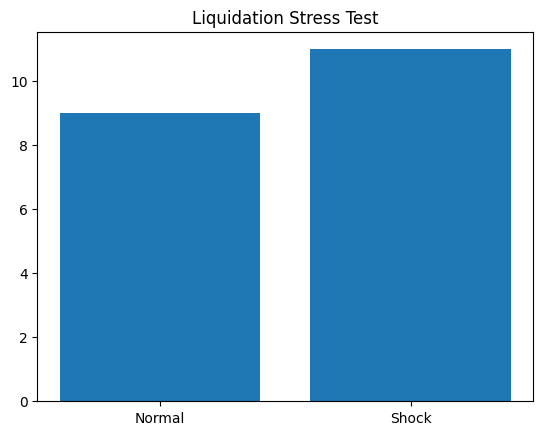

In [37]:
labels = ["Normal", "Shock"]

values = [
    acc_df["liquidation"].sum(),
    acc_df["liquidation_stress"].sum()
]

import matplotlib.pyplot as plt

plt.bar(labels, values)

plt.title("Liquidation Stress Test")

plt.show()

In [38]:
summary = {}

summary["price"] = df["price"].iloc[-1]

summary["rolling_vol"] = df["rolling_vol"].iloc[-1]

summary["rolling_var"] = df["rolling_var"].iloc[-1]

summary["total_accounts"] = len(acc_df)

summary["high_risk"] = (acc_df["risk_ratio"] > 5).sum()

summary["liquidations"] = acc_df["liquidation_v2"].sum()

summary["stress_liquidations"] = acc_df["liquidation_stress"].sum()

summary["insurance_left"] = insurance_after

summary["adl"] = adl_stress

summary  #Dashboard Data

{'price': np.float64(73563.70941008815),
 'rolling_vol': np.float64(0.00409604008262187),
 'rolling_var': np.float64(675.8466136326085),
 'total_accounts': 20,
 'high_risk': np.int64(9),
 'liquidations': np.int64(7),
 'stress_liquidations': np.int64(11),
 'insurance_left': np.int64(-975423),
 'adl': np.True_}

In [39]:
summary_df = pd.DataFrame(summary, index=[0])

summary_df

,price,rolling_vol,rolling_var,total_accounts,high_risk,liquidations,stress_liquidations,insurance_left,adl
0,73563.70941,0.004096,675.846614,20,9,7,11,-975423,True


In [40]:
summary["whales"] = (acc_df["exposure"] > 150000).sum()

summary

{'price': np.float64(73563.70941008815),
 'rolling_vol': np.float64(0.00409604008262187),
 'rolling_var': np.float64(675.8466136326085),
 'total_accounts': 20,
 'high_risk': np.int64(9),
 'liquidations': np.int64(7),
 'stress_liquidations': np.int64(11),
 'insurance_left': np.int64(-975423),
 'adl': np.True_,
 'whales': np.int64(5)}

In [41]:
summary["alerts"] = acc_df["alert"].sum()

summary

{'price': np.float64(73563.70941008815),
 'rolling_vol': np.float64(0.00409604008262187),
 'rolling_var': np.float64(675.8466136326085),
 'total_accounts': 20,
 'high_risk': np.int64(9),
 'liquidations': np.int64(7),
 'stress_liquidations': np.int64(11),
 'insurance_left': np.int64(-975423),
 'adl': np.True_,
 'whales': np.int64(5),
 'alerts': np.int64(0)}

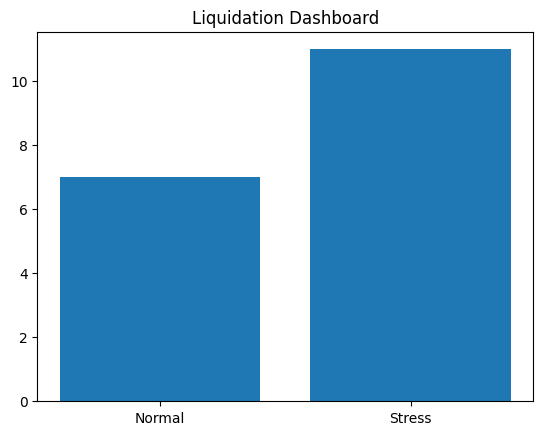

In [42]:
import matplotlib.pyplot as plt

labels = ["Normal", "Stress"]

values = [
    acc_df["liquidation_v2"].sum(),
    acc_df["liquidation_stress"].sum()
]

plt.bar(labels, values)

plt.title("Liquidation Dashboard")

plt.show()

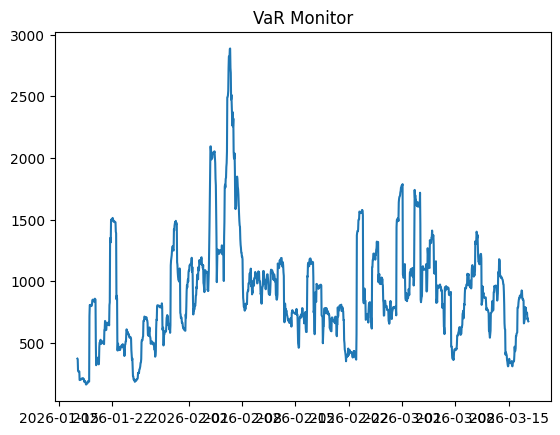

In [43]:
plt.plot(df["time"], df["rolling_var"])

plt.title("VaR Monitor")

plt.show()

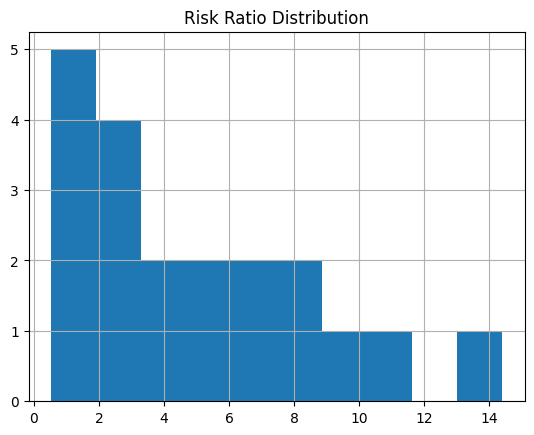

In [44]:
acc_df["risk_ratio"].hist()

plt.title("Risk Ratio Distribution")

plt.show()

In [45]:
acc_df.columns

Index(['account', 'exposure', 'balance', 'risk_ratio', 'market_var',
       'total_risk', 'alert', 'whale', 'liquidation', 'mark_price',
       'bankrupt_price', 'loss', 'margin_rate', 'maintenance_margin',
       'liquidation_v2', 'price', 'shock_price', 'pnl', 'equity_after_shock',
       'liquidation_stress'],
      dtype='object')

In [46]:
acc_df["adl"] = False

if adl_stress:
    acc_df.loc[acc_df["risk_ratio"] > 4, "adl"] = True

acc_df.head()

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,...,loss,margin_rate,maintenance_margin,liquidation_v2,price,shock_price,pnl,equity_after_shock,liquidation_stress,adl
0,0,166916,28693,5.817307,675.846614,3931.607478,False,True,True,73563.70941,...,16691.6,0.20,33383.20,True,73563.70941,58850.967528,-33383.2,-4690.2,True,True
1,1,37391,31318,1.193914,675.846614,806.902763,False,False,False,73563.70941,...,3739.1,0.05,1869.55,False,73563.70941,58850.967528,-7478.2,23839.8,False,False
2,2,102203,48974,2.086883,675.846614,1410.412698,False,False,False,73563.70941,...,10220.3,0.20,20440.60,False,73563.70941,58850.967528,-20440.6,28533.4,False,False
3,3,186252,24789,7.513494,675.846614,5077.969401,False,True,True,73563.70941,...,18625.2,0.20,37250.40,True,73563.70941,58850.967528,-37250.4,-12461.4,True,True
4,4,106682,10138,10.522983,675.846614,7111.922316,False,False,True,73563.70941,...,10668.2,0.20,21336.40,True,73563.70941,58850.967528,-21336.4,-11198.4,True,True


In [47]:
acc_df[
    [
        "account",
        "exposure",
        "balance",
        "risk_ratio",
        "margin_rate",
        "liquidation_v2",
        "liquidation_stress",
        "adl"
    ]
]

,account,exposure,balance,risk_ratio,margin_rate,liquidation_v2,liquidation_stress,adl
0,0,166916,28693,5.817307,0.20,True,True,True
1,1,37391,31318,1.193914,0.05,False,False,False
2,2,102203,48974,2.086883,0.20,False,False,False
3,3,186252,24789,7.513494,0.20,True,True,True
4,4,106682,10138,10.522983,0.20,True,True,True
5,5,157119,22875,6.868590,0.20,True,True,True
6,6,21481,19395,1.107553,0.05,False,False,False
7,7,115963,25838,4.488080,0.20,False,True,True
8,8,183664,12764,14.389220,0.20,True,True,True
9,9,119505,22310,5.356567,0.20,True,True,True
